<a href="https://colab.research.google.com/github/Venky404/Google-Colab-Assignment/blob/main/Assignment_18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Q1. Data Loading & Initial Analysis

In [14]:
# Import pandas library
import pandas as pd

# Load the dataset
df = pd.read_csv("ford_car_dataset.csv")

# Display first 10 rows
print("First 10 Rows:")
print(df.head(10))

# Display last 5 rows
print("\nLast 5 Rows:")
print(df.tail())

# Display dataset shape
print("\nDataset Shape:")
print(df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns)

# Display data types
print("\nData Types:")
print(df.dtypes)

First 10 Rows:
     model  year  price transmission  mileage fuelType  tax   mpg  engineSize
0   Fiesta  2017  12000    Automatic    15944   Petrol  150  57.7         1.0
1    Focus  2018  14000       Manual     9083   Petrol  150  57.7         1.0
2    Focus  2017  13000       Manual    12456   Petrol  150  57.7         1.0
3   Fiesta  2019  17500       Manual    10460   Petrol  145  40.3         1.5
4   Fiesta  2019  16500    Automatic     1482   Petrol  145  48.7         1.0
5   Fiesta  2015  10500       Manual    35432   Petrol  145  47.9         1.6
6     Puma  2019  22500       Manual     2029   Petrol  145  50.4         1.0
7   Fiesta  2017   9000       Manual    13054   Petrol  145  54.3         1.2
8     Kuga  2019  25500    Automatic     6894   Diesel  145  42.2         2.0
9    Focus  2018  10000       Manual    48141   Petrol  145  61.4         1.0

Last 5 Rows:
        model  year  price transmission  mileage fuelType  tax   mpg  \
17961   B-MAX  2017   8999       Manual  

Q2. Missing Values & Duplicate Values

In [2]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate Rows:")
print(df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates()

print("\nShape After Removing Duplicates:")
print(df.shape)

Missing Values:
model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

Duplicate Rows:
154

Shape After Removing Duplicates:
(17812, 9)


Q3. Statistical Summary

In [3]:
# Statistical summary of numeric columns
print(df.describe())

# Mean, Median, Minimum and Maximum values

print("\nPrice Statistics")
print("Mean:", df["price"].mean())
print("Median:", df["price"].median())
print("Minimum:", df["price"].min())
print("Maximum:", df["price"].max())

print("\nMileage Statistics")
print("Mean:", df["mileage"].mean())
print("Median:", df["mileage"].median())
print("Minimum:", df["mileage"].min())
print("Maximum:", df["mileage"].max())

print("\nYear Statistics")
print("Mean:", df["year"].mean())
print("Median:", df["year"].median())
print("Minimum:", df["year"].min())
print("Maximum:", df["year"].max())

               year         price        mileage           tax           mpg  \
count  17812.000000  17812.000000   17812.000000  17812.000000  17812.000000   
mean    2016.862396  12269.556310   23381.146362    113.315012     57.908696   
std        2.052039   4736.285417   19419.011045     62.034603     10.132696   
min     1996.000000    495.000000       1.000000      0.000000     20.800000   
25%     2016.000000   8999.000000   10000.000000     30.000000     52.300000   
50%     2017.000000  11288.000000   18277.000000    145.000000     58.900000   
75%     2018.000000  15295.000000   31098.500000    145.000000     65.700000   
max     2060.000000  54995.000000  177644.000000    580.000000    201.800000   

         engineSize  
count  17812.000000  
mean       1.350623  
std        0.432581  
min        0.000000  
25%        1.000000  
50%        1.200000  
75%        1.500000  
max        5.000000  

Price Statistics
Mean: 12269.556310352571
Median: 11288.0
Minimum: 495
Maximum: 

Q4. Histogram of Numeric Features

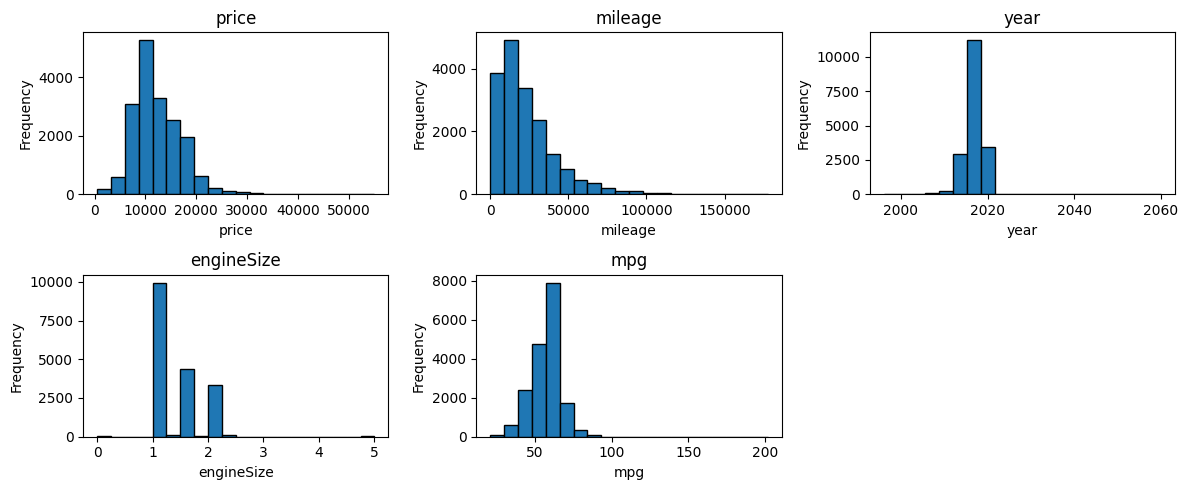

In [18]:
# Import required libraries
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

# Numerical columns
numeric_columns = ['price', 'mileage', 'year', 'engineSize', 'mpg']

# Create a 2x3 grid
fig, axes = plt.subplots(2, 3, figsize=(12, 5))

axes = axes.ravel()   # Convert axes into a 1D array

for i, column in enumerate(numeric_columns):
    axes[i].hist(df[column], bins=20, edgecolor='black')
    axes[i].set_title(column)
    axes[i].set_xlabel(column)
    axes[i].set_ylabel("Frequency")

# Hide the last empty subplot
axes[-1].axis('off')

plt.tight_layout()
plt.show()

Q5. Count Plots of Categorical Features

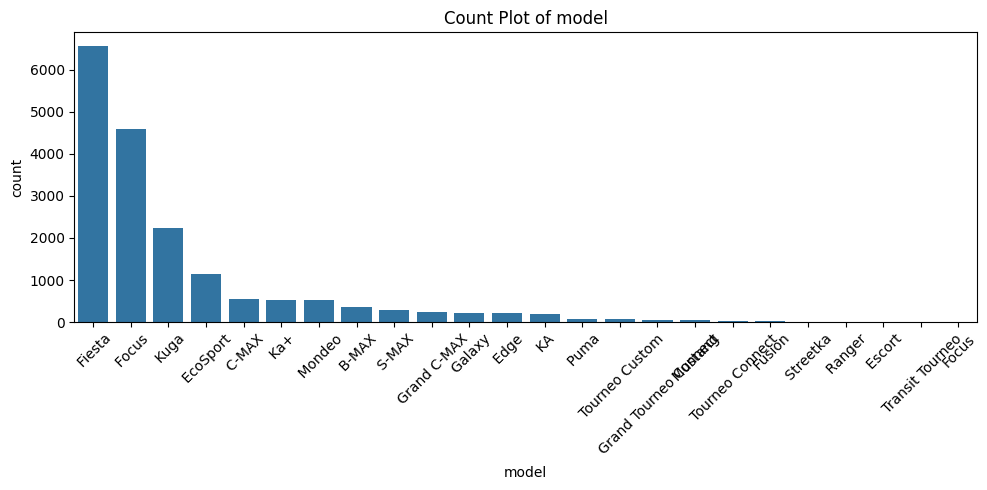

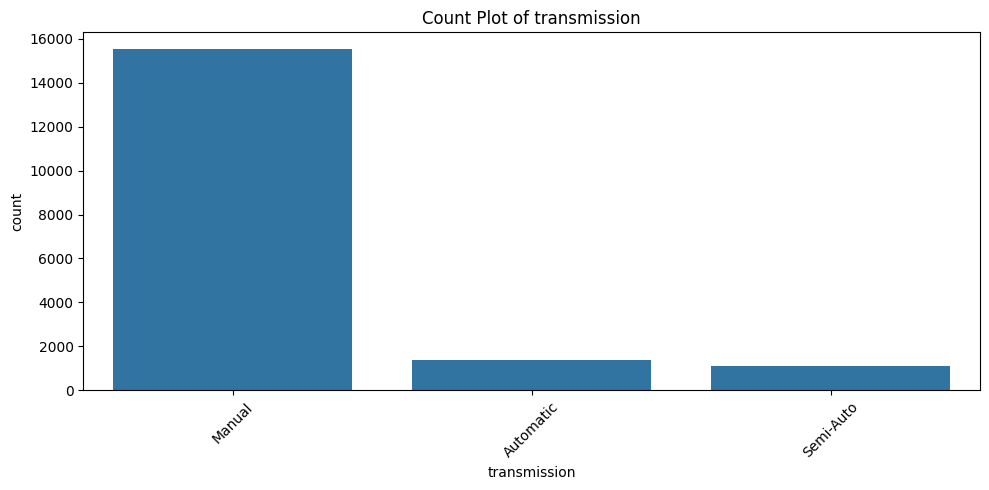

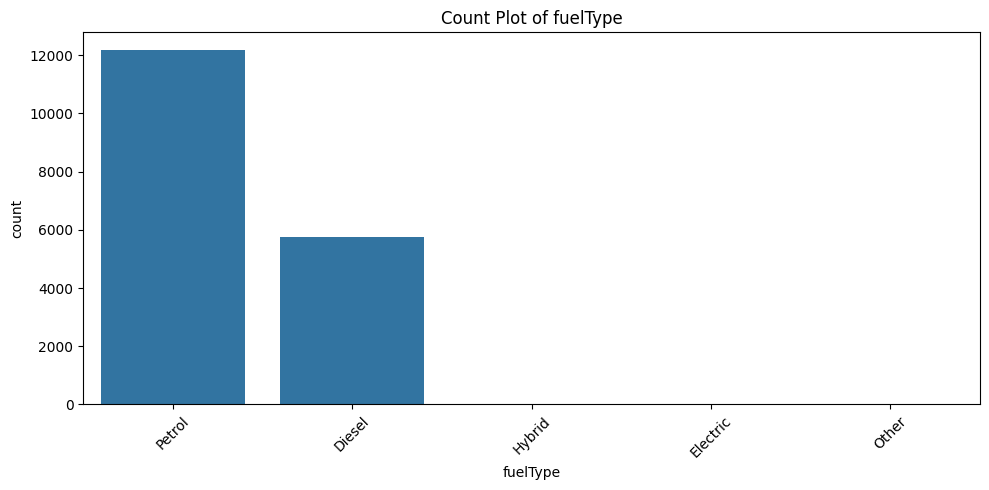

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Find categorical columns
categorical_columns = df.select_dtypes(include='object').columns

# Create count plots
for column in categorical_columns:
    plt.figure(figsize=(10,5))
    sns.countplot(data=df, x=column, order=df[column].value_counts().index)

    plt.title(f'Count Plot of {column}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Q6. Correlation Heatmap

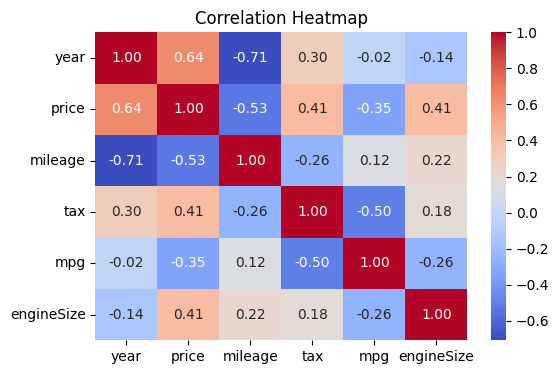

In [21]:
# Correlation Heatmap

plt.figure(figsize=(6,4))

correlation = df.corr(numeric_only=True)

sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title("Correlation Heatmap")
plt.show()

In [7]:
print("Correlation with Price:")
print(correlation["price"].sort_values(ascending=False))

Correlation with Price:
price         1.000000
year          0.635715
engineSize    0.411451
tax           0.405969
mpg          -0.346263
mileage      -0.530483
Name: price, dtype: float64


Q7. Feature Identification

In [8]:
# Independent (Input) Features
X = df.drop("price", axis=1)

# Dependent (Output) Feature
y = df["price"]

print("Independent Features (X):")
print(X.columns)

print("\nDependent Feature (y):")
print(y.name)

Independent Features (X):
Index(['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg',
       'engineSize'],
      dtype='object')

Dependent Feature (y):
price


Q8. Encoding Categorical Variables (One-Hot Encoding)

In [9]:
# Display first 5 rows before encoding

print("Before Encoding:")
print(df[['model', 'transmission']].head())

Before Encoding:
     model transmission
0   Fiesta    Automatic
1    Focus       Manual
2    Focus       Manual
3   Fiesta       Manual
4   Fiesta    Automatic


In [10]:
# One-Hot Encoding

encoded_df = pd.get_dummies(
    df,
    columns=['model', 'transmission', 'fuelType'],
    drop_first=True
)

print("\nAfter Encoding:")
print(encoded_df.head())


After Encoding:
   year  price  mileage  tax   mpg  engineSize  model_ C-MAX  model_ EcoSport  \
0  2017  12000    15944  150  57.7         1.0         False            False   
1  2018  14000     9083  150  57.7         1.0         False            False   
2  2017  13000    12456  150  57.7         1.0         False            False   
3  2019  17500    10460  145  40.3         1.5         False            False   
4  2019  16500     1482  145  48.7         1.0         False            False   

   model_ Edge  model_ Escort  ...  model_ Tourneo Connect  \
0        False          False  ...                   False   
1        False          False  ...                   False   
2        False          False  ...                   False   
3        False          False  ...                   False   
4        False          False  ...                   False   

   model_ Tourneo Custom  model_ Transit Tourneo  model_Focus  \
0                  False                   False        Fa

Q9. Feature Scaling

In [11]:
from sklearn.preprocessing import StandardScaler

# Independent features
X = encoded_df.drop("price", axis=1)

# Target feature
y = encoded_df["price"]

# Numerical columns
numerical_columns = [
    'year',
    'mileage',
    'tax',
    'mpg',
    'engineSize'
]

# Apply Standard Scaling
scaler = StandardScaler()

X[numerical_columns] = scaler.fit_transform(X[numerical_columns])

print("First 5 Rows of Scaled Data:")
print(X.head())

First 5 Rows of Scaled Data:
       year   mileage       tax       mpg  engineSize  model_ C-MAX  \
0  0.067059 -0.382994  0.591380 -0.020597   -0.810561         False   
1  0.554393 -0.736317  0.591380 -0.020597   -0.810561         False   
2  0.067059 -0.562616  0.591380 -0.020597   -0.810561         False   
3  1.041726 -0.665405  0.510777 -1.737858    0.345325         False   
4  1.041726 -1.127749  0.510777 -0.908836   -0.810561         False   

   model_ EcoSport  model_ Edge  model_ Escort  model_ Fiesta  ...  \
0            False        False          False           True  ...   
1            False        False          False          False  ...   
2            False        False          False          False  ...   
3            False        False          False           True  ...   
4            False        False          False           True  ...   

   model_ Tourneo Connect  model_ Tourneo Custom  model_ Transit Tourneo  \
0                   False                  Fals

Q10. Complete Preprocessing Pipeline

Missing Values
model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64


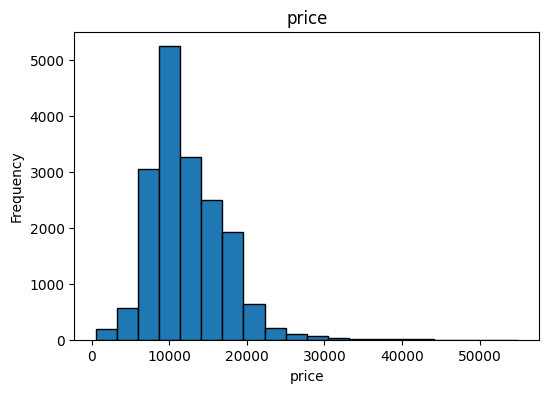

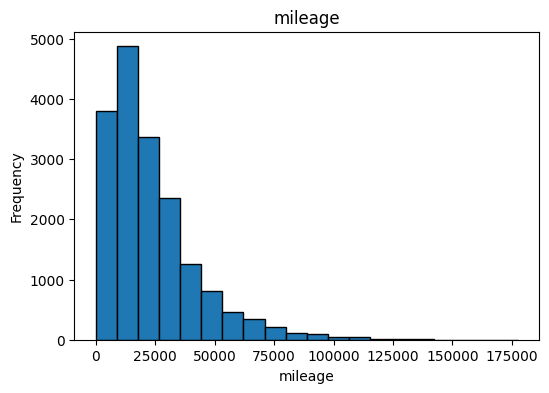

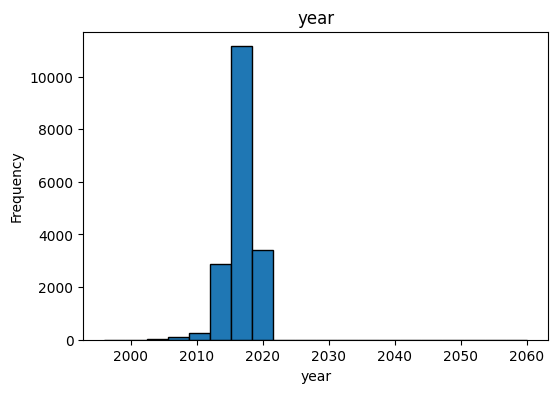

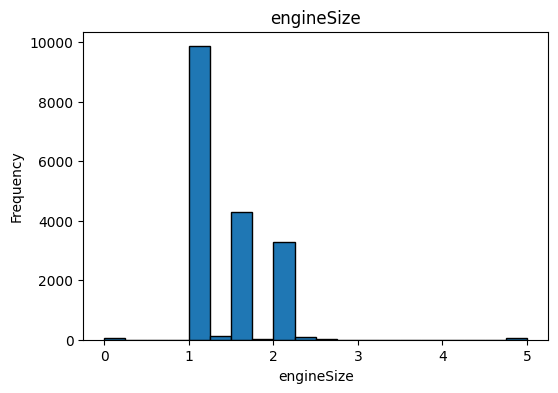

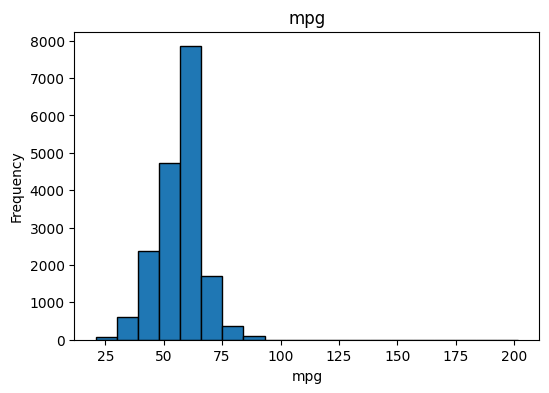

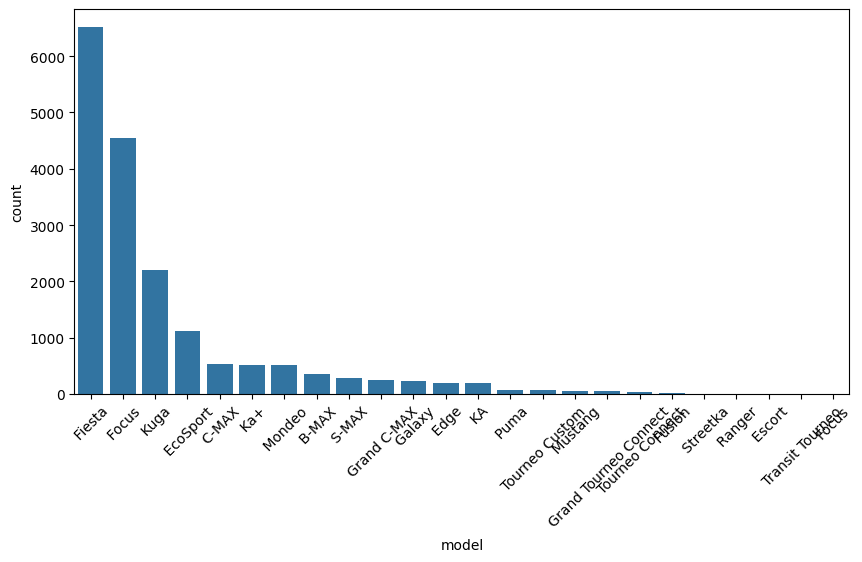

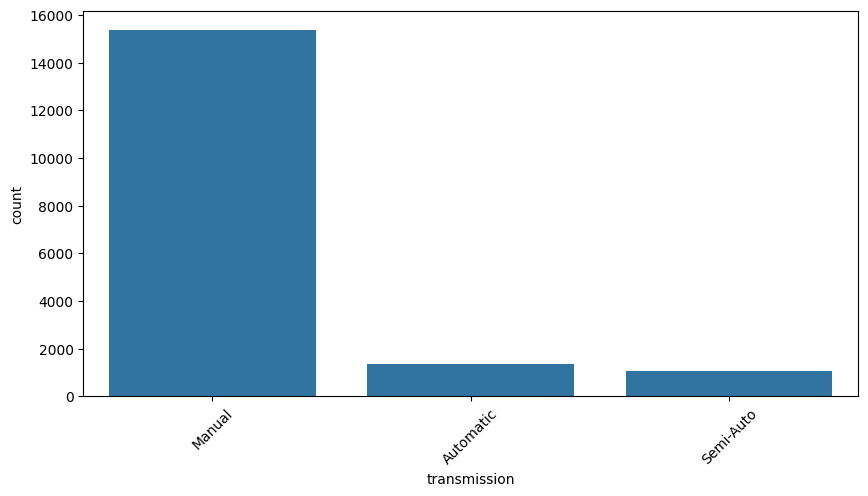

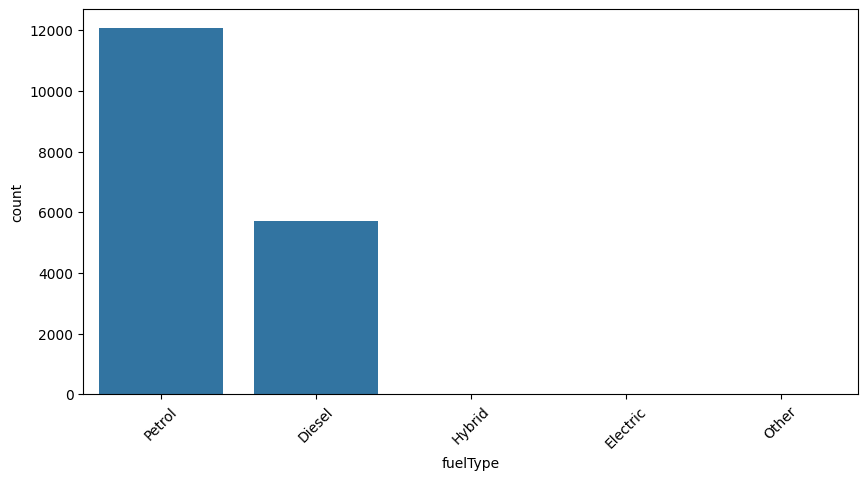

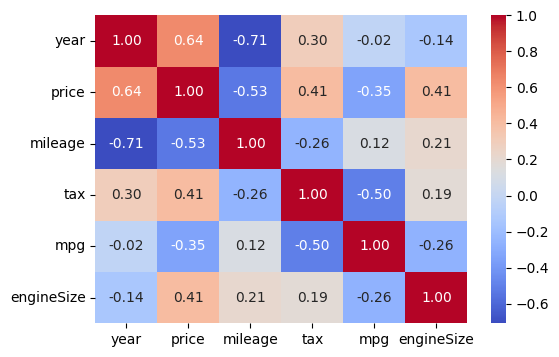


Preprocessing Completed Successfully

Final Shape of Input Features:
(17812, 34)

Target Shape:
(17812,)

First 5 Rows:
       year   mileage       tax       mpg  engineSize  model_ C-MAX  \
0  0.067059 -0.382994  0.591380 -0.020597   -0.810561         False   
1  0.554393 -0.736317  0.591380 -0.020597   -0.810561         False   
2  0.067059 -0.562616  0.591380 -0.020597   -0.810561         False   
3  1.041726 -0.665405  0.510777 -1.737858    0.345325         False   
4  1.041726 -1.127749  0.510777 -0.908836   -0.810561         False   

   model_ EcoSport  model_ Edge  model_ Escort  model_ Fiesta  ...  \
0            False        False          False           True  ...   
1            False        False          False          False  ...   
2            False        False          False          False  ...   
3            False        False          False           True  ...   
4            False        False          False           True  ...   

   model_ Tourneo Connect  mode

In [22]:
# ===============================
# COMPLETE PREPROCESSING PIPELINE
# ===============================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

# Step 1 : Load Dataset
df = pd.read_csv("ford_car_dataset.csv")

# Step 2 : Check Missing Values
print("Missing Values")
print(df.isnull().sum())

# Step 3 : Remove Duplicate Rows
df = df.drop_duplicates()

# Step 4 : Histogram
numeric_columns = ['price', 'mileage', 'year', 'engineSize', 'mpg']

for column in numeric_columns:
    plt.figure(figsize=(6,4))
    plt.hist(df[column], bins=20, edgecolor='black')
    plt.title(column)
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

# Step 5 : Count Plots
categorical_columns = df.select_dtypes(include='object').columns

for column in categorical_columns:
    plt.figure(figsize=(10,5))
    sns.countplot(data=df,
                  x=column,
                  order=df[column].value_counts().index)
    plt.xticks(rotation=45)
    plt.show()

# Step 6 : Heatmap
plt.figure(figsize=(6,4))

corr = df.corr(numeric_only=True)

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.show()

# Step 7 : Identify Features
X = df.drop("price", axis=1)
y = df["price"]

# Step 8 : One-Hot Encoding
X = pd.get_dummies(
    X,
    columns=['model', 'transmission', 'fuelType'],
    drop_first=True
)

# Step 9 : Standard Scaling
scaler = StandardScaler()

num_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize']

X[num_cols] = scaler.fit_transform(X[num_cols])

print("\nPreprocessing Completed Successfully")
print("\nFinal Shape of Input Features:")
print(X.shape)

print("\nTarget Shape:")
print(y.shape)

print("\nFirst 5 Rows:")
print(X.head())